In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import folium
import wordcloud

constructors = pd.read_csv('collection/clean_data/constructors.csv')
raceResults = pd.read_csv('collection/clean_data/results.csv')
drivers = pd.read_csv('collection/clean_data/drivers.csv')
races = pd.read_csv('collection/clean_data/races.csv')
circuits = pd.read_csv('collection/clean_data/circuits.csv')
drivers_standings = pd.read_csv('collection/clean_data/drivers_standings.csv')
constructors_standings = pd.read_csv('collection/clean_data/constructors_standings.csv')

C:\Users\Iva Nikolova\AppData\Local\Temp\ipykernel_26132\3632649084.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winners_top_5['cumulative_wins'] = winners_top_5.groupby('name_y')['wins'].cumsum()
c:\Users\Iva Nikolova\Downloads\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Iva Nikolova\Downloads\Anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as

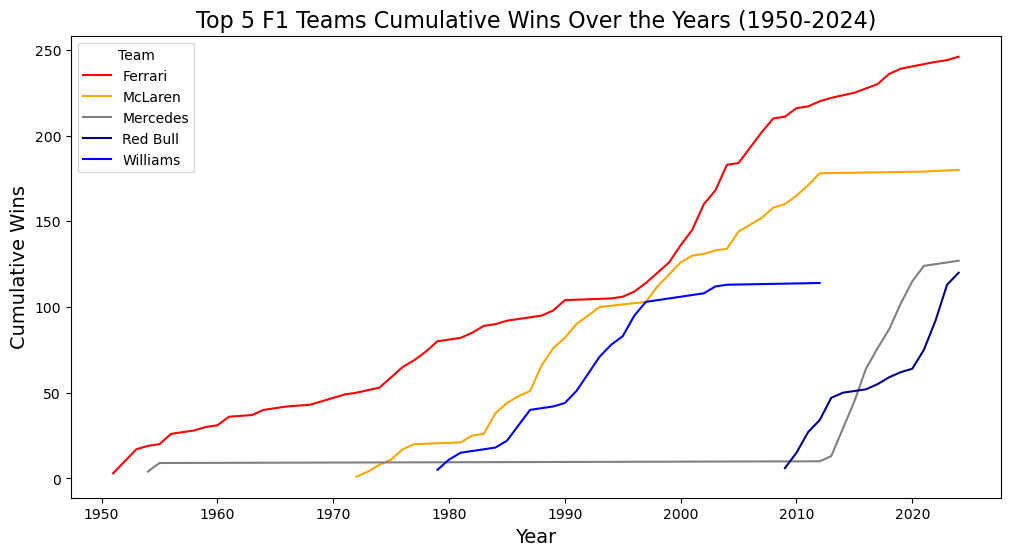

In [18]:
winners = raceResults[raceResults['position'] == '1']

winners = winners.merge(races, on='raceId', how='inner')

winners = winners.merge(constructors, on='constructorId', how='inner')
winners = winners[['name_y', 'year']]
winners = winners.groupby(['name_y', 'year']).size().reset_index(name='wins')

winners_grouped = winners.groupby(['name_y', 'year'])['wins'].sum().reset_index()

total_wins = winners_grouped.groupby('name_y')['wins'].sum().reset_index()

top_5_teams = total_wins.nlargest(5, 'wins')['name_y']

winners_top_5 = winners_grouped[winners_grouped['name_y'].isin(top_5_teams)]

winners_top_5['cumulative_wins'] = winners_top_5.groupby('name_y')['wins'].cumsum()

color_mapping = {
    'Ferrari': 'red',
    'McLaren': 'orange',
    'Mercedes': 'grey',
    'Red Bull': 'darkblue',
    'Williams': 'blue'
}

plt.figure(figsize=(12, 6))

sns.lineplot(data=winners_top_5, x='year', y='cumulative_wins', hue='name_y', palette=color_mapping)

plt.title('Top 5 F1 Teams Cumulative Wins Over the Years (1950-2024)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Cumulative Wins', fontsize=14)
plt.legend(title='Team')

plt.show()

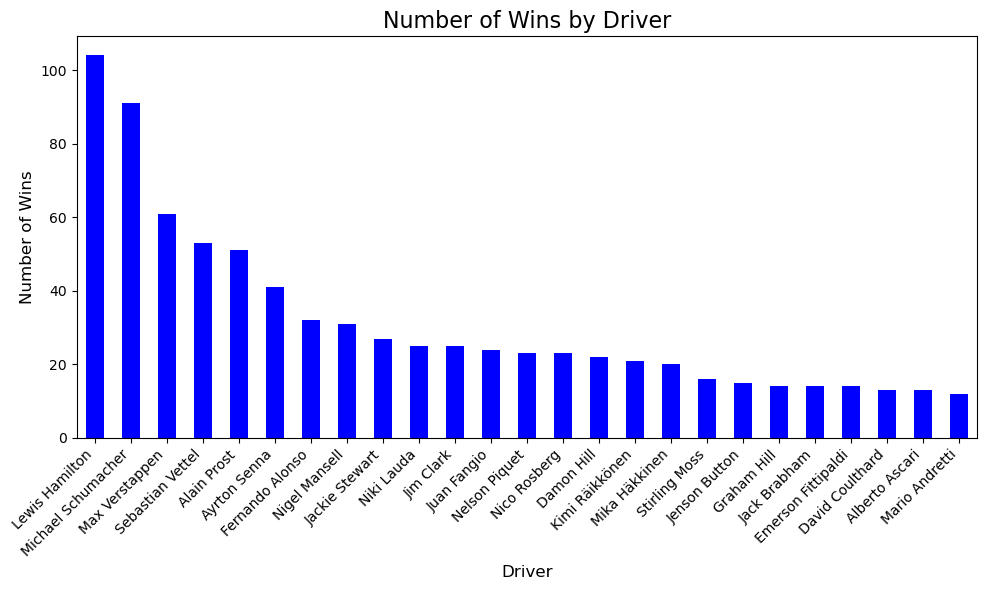

In [96]:
winners = raceResults[raceResults['position'] == '1']
winners = winners[['driverId']]

winners = winners.merge(drivers, on='driverId', how='inner')
winners['Full_Name'] = winners['forename'].astype(str) + ' ' + winners['surname'].astype(str)
driver_wins = winners['Full_Name'].value_counts()
top_25_drivers = driver_wins.head(25)

plt.figure(figsize=(10, 6))
top_25_drivers.plot(kind='bar', color='blue')

plt.title('Number of Wins by Driver', fontsize=16)
plt.xlabel('Driver', fontsize=12)
plt.ylabel('Number of Wins', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

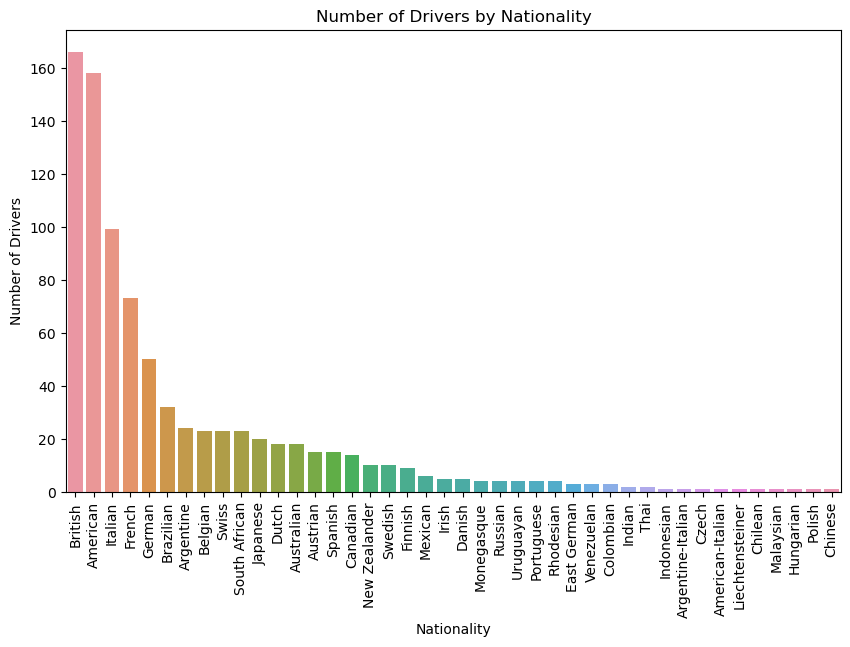

In [20]:
# Number of drivers by Nationaly
nationality_counts = drivers['nationality'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=nationality_counts.index, y=nationality_counts.values)
plt.title('Number of Drivers by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Number of Drivers')
plt.xticks(rotation=90)
plt.show()

In [21]:
unique_years = races['year'].unique()
print("Available years in the dataset: ", unique_years)

races_per_year = races[races['year'] == 2020]

# Select the relevant columns
races_per_year_info = races_per_year[['name', 'date']]

# Display the results
print("Races in 2020:")
print(races_per_year_info.reset_index(drop=True))

Available years in the dataset:  [2009 2008 2007 2006 2005 2004 2003 2002 2001 2000 1999 1998 1997 1996
 1995 1994 1993 1992 1991 1990 2010 1989 1988 1987 1986 1985 1984 1983
 1982 1981 1980 1979 1978 1977 1976 1975 1974 1973 1972 1971 1970 1969
 1968 1967 1966 1965 1964 1963 1962 1961 1960 1959 1958 1957 1956 1955
 1954 1953 1952 1951 1950 2011 2012 2013 2014 2015 2016 2017 2018 2019
 2020 2021 2022 2023 2024]
Races in 2020:
                           name        date
0           Austrian Grand Prix  2020-07-05
1            Styrian Grand Prix  2020-07-12
2          Hungarian Grand Prix  2020-07-19
3            British Grand Prix  2020-08-02
4   70th Anniversary Grand Prix  2020-08-09
5            Spanish Grand Prix  2020-08-16
6            Belgian Grand Prix  2020-08-30
7            Italian Grand Prix  2020-09-06
8             Tuscan Grand Prix  2020-09-13
9            Russian Grand Prix  2020-09-27
10             Eifel Grand Prix  2020-10-11
11        Portuguese Grand Prix  2020-10-2

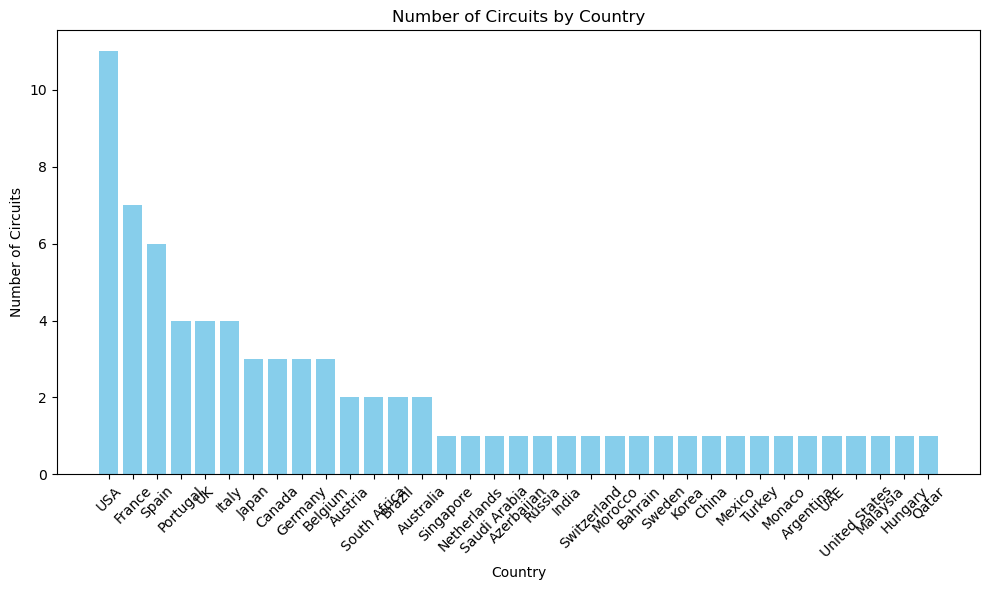

In [22]:
# Count the number of circuits by country
circuit_counts = circuits['country'].value_counts()

# Convert the Series to a DataFrame for easier manipulation
circuit_counts_df = circuit_counts.reset_index()
circuit_counts_df.columns = ['Country', 'Number of Circuits']

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(circuit_counts_df['Country'], circuit_counts_df['Number of Circuits'], color='skyblue')
plt.xlabel('Country')
plt.ylabel('Number of Circuits')
plt.title('Number of Circuits by Country')
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

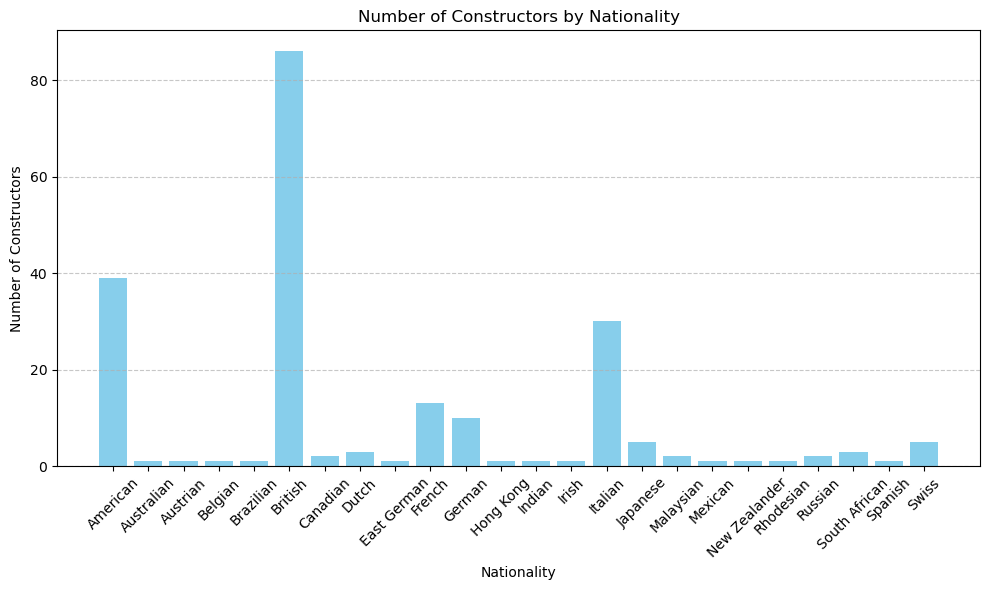

In [23]:
# Group by nationality
constructor_count = (
    constructors.groupby('nationality')
    .agg(
        Number_of_Constructors=('constructorId', 'size'),
        Constructor_Names=('name', lambda x: ', '.join(x))
    )
    .reset_index()
)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(constructor_count['nationality'], constructor_count['Number_of_Constructors'], color='skyblue')
plt.title('Number of Constructors by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Number of Constructors')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [98]:
# Nationality to ISO 3166-1 alpha-3 country code mapping
nationality_to_iso3 = {
    'Afghan': 'AFG',
    'Albanian': 'ALB',
    'Algerian': 'DZA',
    'American': 'USA',
    'Andorran': 'AND',
    'Angolan': 'AGO',
    'Argentine': 'ARG',
    'Armenian': 'ARM',
    'Australian': 'AUS',
    'Austrian': 'AUT',
    'Azerbaijani': 'AZE',
    'Bahamian': 'BHS',
    'Bahraini': 'BHR',
    'Bangladeshi': 'BGD',
    'Barbadian': 'BRB',
    'Belarusian': 'BLR',
    'Belgian': 'BEL',
    'Belizean': 'BLZ',
    'Beninese': 'BEN',
    'Bhutanese': 'BTN',
    'Bolivian': 'BOL',
    'Bosnian': 'BIH',
    'Botswanan': 'BWA',
    'Brazilian': 'BRA',
    'British': 'GBR',
    'Bruneian': 'BRN',
    'Bulgarian': 'BGR',
    'Burkinabé': 'BFA',
    'Burundian': 'BDI',
    'Cabo Verdean': 'CPV',
    'Cambodian': 'KHM',
    'Canadian': 'CAN',
    'Central African': 'CAF',
    'Chadian': 'TCD',
    'Chilean': 'CHL',
    'Chinese': 'CHN',
    'Colombian': 'COL',
    'Comorian': 'COM',
    'Congolese': 'COG',
    'Costa Rican': 'CRI',
    'Croatian': 'HRV',
    'Cuban': 'CUB',
    'Cypriot': 'CYP',
    'Czech': 'CZE',
    'Danish': 'DNK',
    'Djiboutian': 'DJI',
    'Dominican': 'DOM',
    'Dutch': 'NLD',
    'Ecuadorian': 'ECU',
    'Egyptian': 'EGY',
    'Salvadoran': 'SLV',
    'Equatorial Guinean': 'GNQ',
    'Eritrean': 'ERI',
    'Estonian': 'EST',
    'Eswatini': 'SWZ',
    'Ethiopian': 'ETH',
    'Fijian': 'FJI',
    'Finnish': 'FIN',
    'French': 'FRA',
    'Gabonese': 'GAB',
    'Gambian': 'GMB',
    'Georgian': 'GEO',
    'German': 'DEU',
    'Ghanaian': 'GHA',
    'Greek': 'GRC',
    'Grenadian': 'GRD',
    'Guatemalan': 'GTM',
    'Guinean': 'GIN',
    'Haitian': 'HTI',
    'Honduran': 'HND',
    'Hungarian': 'HUN',
    'Icelandic': 'ISL',
    'Indian': 'IND',
    'Indonesian': 'IDN',
    'Iranian': 'IRN',
    'Iraqi': 'IRQ',
    'Irish': 'IRL',
    'Israeli': 'ISR',
    'Italian': 'ITA',
    'Ivorian': 'CIV',
    'Jamaican': 'JAM',
    'Japanese': 'JPN',
    'Jordanian': 'JOR',
    'Kazakh': 'KAZ',
    'Kenyan': 'KEN',
    'Kuwaiti': 'KWT',
    'Kyrgyz': 'KGZ',
    'Laotian': 'LAO',
    'Latvian': 'LVA',
    'Lebanese': 'LBN',
    'Liberian': 'LBR',
    'Libyan': 'LBY',
    'Lithuanian': 'LTU',
    'Luxembourger': 'LUX',
    'Malawian': 'MWI',
    'Malaysian': 'MYS',
    'Malian': 'MLI',
    'Maldivian': 'MDV',
    'Maltese': 'MLT',
    'Mexican': 'MEX',
    'Moldovan': 'MDA',
    'Monacan': 'MCO',
    'Mongolian': 'MNG',
    'Moroccan': 'MAR',
    'Mozambican': 'MOZ',
    'Namibian': 'NAM',
    'Nauruan': 'NRU',
    'Nepalese': 'NPL',
    'New Zealander': 'NZL',
    'Nigerien': 'NER',
    'Nigerian': 'NGA',
    'North Korean': 'PRK',
    'Norwegian': 'NOR',
    'Omani': 'OMN',
    'Pakistani': 'PAK',
    'Panamanian': 'PAN',
    'Papua New Guinean': 'PNG',
    'Paraguayan': 'PRY',
    'Peruvian': 'PER',
    'Philippine': 'PHL',
    'Polish': 'POL',
    'Portuguese': 'PRT',
    'Qatari': 'QAT',
    'Romanian': 'ROU',
    'Russian': 'RUS',
    'Rwandan': 'RWA',
    'Saudi': 'SAU',
    'Senegalese': 'SEN',
    'Serbian': 'SRB',
    'Seychellois': 'SYC',
    'Sierra Leonean': 'SLE',
    'Singaporean': 'SGP',
    'Slovak': 'SVK',
    'Slovenian': 'SVN',
    'Somali': 'SOM',
    'South African': 'ZAF',
    'South Korean': 'KOR',
    'Spanish': 'ESP',
    'Sri Lankan': 'LKA',
    'Sudanese': 'SDN',
    'Surinamese': 'SUR',
    'Swedish': 'SWE',
    'Swiss': 'CHE',
    'Syrian': 'SYR',
    'Taiwanese': 'TWN',
    'Tajik': 'TJK',
    'Tanzanian': 'TZA',
    'Thai': 'THA',
    'Togolese': 'TGO',
    'Trinidadian': 'TTO',
    'Tunisian': 'TUN',
    'Turkish': 'TUR',
    'Turkmen': 'TKM',
    'Ugandan': 'UGA',
    'Ukrainian': 'UKR',
    'Emirati': 'ARE',
    'Uruguayan': 'URY',
    'Uzbek': 'UZB',
    'Venezuelan': 'VEN',
    'Vietnamese': 'VNM',
    'Yemeni': 'YEM',
    'Zambian': 'ZMB',
    'Zimbabwean': 'ZWE'
}


In [25]:
map_data = drivers.groupby('nationality').size().reset_index(name='number')

geojson_url = 'https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json'
response = requests.get(geojson_url)

map_data['country_code'] = map_data['nationality'].map(nationality_to_iso3)
map_data = map_data[['number','country_code']]
map_data = map_data.dropna(subset=['country_code'])
geojson = response.json()

In [26]:
M = folium.Map(location=[20,10], zoom_start=2)

# Create the Choropleth layer
folium.Choropleth(
    geo_data=geojson,
    data=map_data,
    columns=['country_code', 'number'],
    key_on='feature.id',
    fill_color='YlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
).add_to(M)

M

In [99]:
# Step 1: Aggregate the number of teams by nationality
team_data = constructors.groupby('nationality').size().reset_index(name='number')

# Step 2: Map nationalities to ISO3 country codes
team_data['country_code'] = team_data['nationality'].map(nationality_to_iso3)
# Remove rows with no country code
team_data = team_data.dropna(subset=['country_code'])

# Step 3: Fetch GeoJSON data for countries
geojson_url = 'https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json'
response = requests.get(geojson_url)
geojson = response.json()

# Step 4: Create the Folium Map
M = folium.Map(location=[20, 10], zoom_start=3)

# Add Choropleth layer for team counts by country
folium.Choropleth(
    geo_data=geojson,
    data=team_data,
    columns=['country_code', 'number'],
    key_on='feature.id',
    fill_color='YlGn',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Number of Teams by Nationality'
).add_to(M)

# Display the map
M

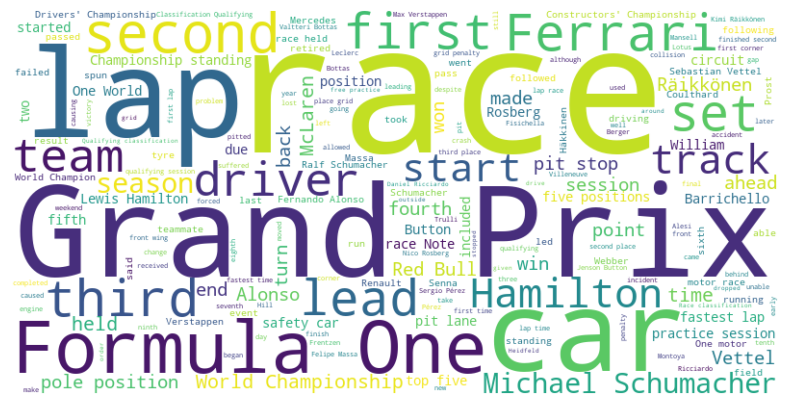

In [33]:
all_text = " ".join(str(row) for row in races['summary'].fillna(''))

wordcloud = wordcloud.WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

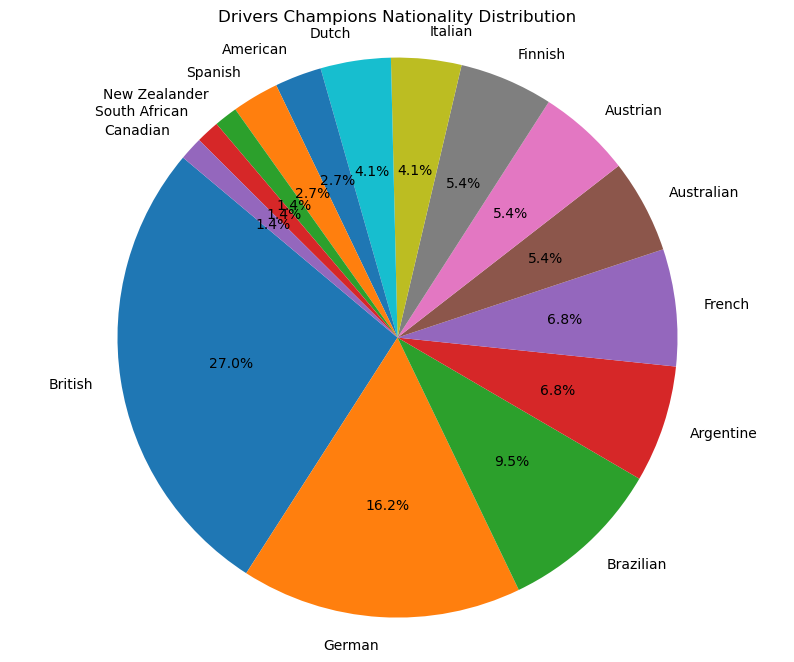

In [29]:
drivers_standings = drivers_standings[drivers_standings['position'] == 1]

drivers_nationality = drivers_standings.merge(drivers, on='driverId', how='inner')
drivers_nationality = drivers_nationality[['nationality']]

nationality_count_df = drivers_nationality['nationality'].value_counts().reset_index()
nationality_count_df.columns = ['nationality', 'count']

plt.figure(figsize=(10, 8))
plt.pie(nationality_count_df['count'], labels=nationality_count_df['nationality'], autopct='%1.1f%%', startangle=140)
plt.title('Drivers Champions Nationality Distribution')
plt.axis('equal')
plt.show()


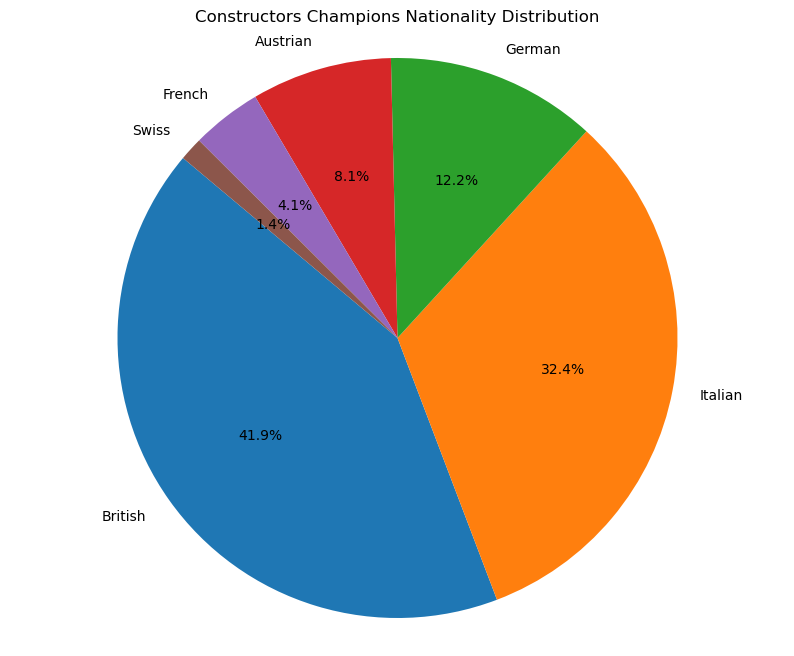

In [30]:
constructors_standings = constructors_standings[constructors_standings['position'] == 1]

constructors_nationality = constructors_standings.merge(constructors, on='constructorId', how='inner')
constructors_nationality = constructors_nationality[['nationality']]

nationality_count_df = constructors_nationality['nationality'].value_counts().reset_index()
nationality_count_df.columns = ['nationality', 'count']

plt.figure(figsize=(10, 8))
plt.pie(nationality_count_df['count'], labels=nationality_count_df['nationality'], autopct='%1.1f%%', startangle=140)
plt.title('Constructors Champions Nationality Distribution')
plt.axis('equal')

plt.show()


In [2]:
raceResults

,raceId,driverId,constructorId,number,grid,position,points,statusId
0,18,1,1,22,1,1,10.0,1
1,18,2,2,3,5,2,8.0,1
2,18,3,3,7,7,3,6.0,1
3,18,4,4,5,11,4,5.0,1
4,18,5,1,23,3,5,4.0,1
...,...,...,...,...,...,...,...,...
26514,1132,839,214,31,18,16,0.0,12
26515,1132,815,9,11,0,17,0.0,12
26516,1132,855,15,24,14,18,0.0,12
26517,1132,847,131,63,1,\N,0.0,34


<Figure size 1000x600 with 0 Axes>

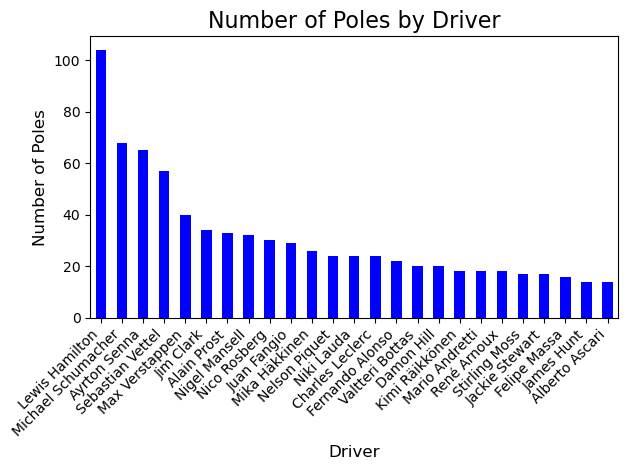

In [17]:
quali = raceResults[raceResults['grid'] == 1]
quali_grouped = quali.groupby(['driverId']).size().reset_index(name='poles')
quali_grouped = quali_grouped.merge(drivers, on='driverId', how='inner')

quali_grouped['fullname'] = quali_grouped['forename'] + ' ' + quali_grouped['surname']

quali_grouped = quali_grouped[['fullname', 'poles']].sort_values(by='poles', ascending=False)

plt.figure(figsize=(10, 6))
quali_grouped.head(25).plot(kind='bar', x='fullname', y='poles', legend=False, color='blue')

plt.title('Number of Poles by Driver', fontsize=16)
plt.xlabel('Driver', fontsize=12)
plt.ylabel('Number of Poles', fontsize=12)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()

plt.show()

C:\Users\35193\AppData\Local\Temp\ipykernel_8400\1975359853.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quali_pole['won'] = quali_pole['position'] == '1'  # Ensure 'position' is compared as a string if necessary


Filtered Drivers by Conversion Ratio (≥50%):
                 fullname  poles  wins  conversion_ratio
51             Jo Siffert      2   1.0         50.000000
81           Nico Rosberg     30  15.0         50.000000
73       Michele Alboreto      2   1.0         50.000000
54           John Surtees      8   4.0         50.000000
42             James Hunt     14   7.0         50.000000
32      Gilles Villeneuve      2   1.0         50.000000
31   Giancarlo Fisichella      4   2.0         50.000000
105           Tony Brooks      4   2.0         50.000000
26           Felipe Massa     16   8.0         50.000000
8        Carlos Reutemann      6   3.0         50.000000
82          Nigel Mansell     32  17.0         53.125000
98       Sebastian Vettel     57  31.0         54.385965
0             Alain Prost     33  18.0         54.545455
64         Lewis Hamilton    104  61.0         58.653846
72     Michael Schumacher     68  40.0         58.823529
47          Jenson Button      8   5.0     

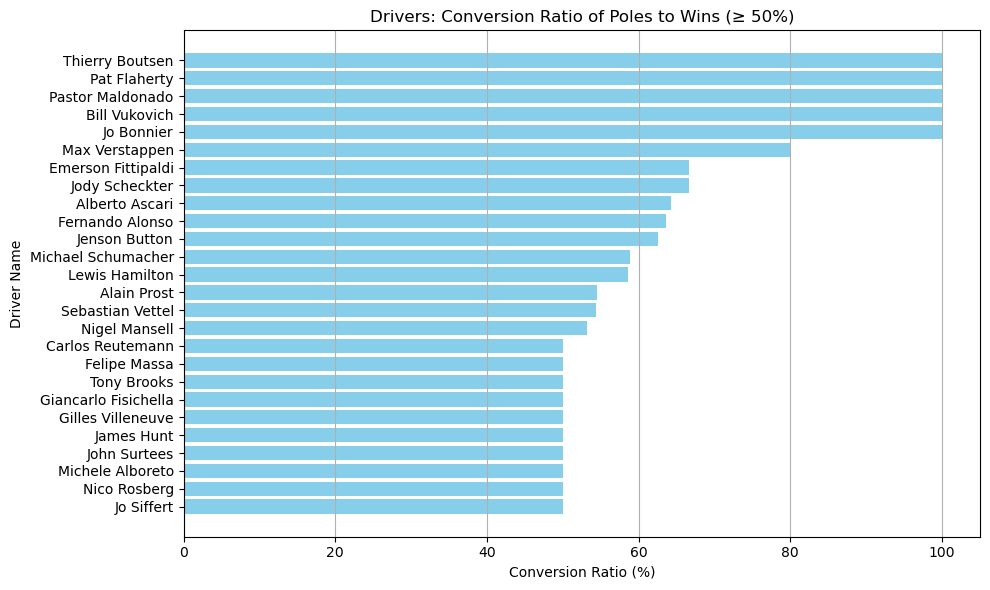

In [95]:
# Assuming raceResults and drivers DataFrames are already defined

# Filter qualifying results where the grid position is 1 (pole)
quali_pole = raceResults[raceResults['grid'] == 1]

# Create a new column to check if the driver also won the race
quali_pole['won'] = quali_pole['position'] == '1'  # Ensure 'position' is compared as a string if necessary

# Group by driverId to count poles only
quali_pole_grouped = quali_pole.groupby('driverId').size().reset_index(name='poles')

# Group by driverId to count wins where the driver won starting from pole
quali_pole_and_win_grouped = quali_pole[quali_pole['won']].groupby('driverId').size().reset_index(name='wins')

# Merge the two DataFrames on driverId (including drivers with no wins)
result = pd.merge(quali_pole_grouped, quali_pole_and_win_grouped, on='driverId', how='left').fillna(0)

# Merge with drivers DataFrame to get full names
result = result.merge(drivers[['driverId', 'forename', 'surname']], on='driverId', how='inner')

# Create a full name column
result['fullname'] = result['forename'] + ' ' + result['surname']

# Group by fullname to combine poles and wins
result_grouped = result.groupby('fullname').agg({'poles': 'sum', 'wins': 'sum'}).reset_index()

# Calculate the conversion ratio as a percentage
result_grouped['conversion_ratio'] = (result_grouped['wins'] / result_grouped['poles'].replace(0, float('nan'))) * 100  # Conversion to percentage
result_grouped['conversion_ratio'] = result_grouped['conversion_ratio'].fillna(0)  # Handle division by zero

# Define the percentage threshold for filtering (e.g., 50%)
percentage_threshold = 50

# Filter by percentage threshold
filtered_results = result_grouped[result_grouped['conversion_ratio'] >= percentage_threshold]

# Sort the filtered results by conversion ratio in ascending order
filtered_sorted = filtered_results.sort_values(by='conversion_ratio', ascending=True)

# Print the filtered and sorted result for debugging
print("Filtered Drivers by Conversion Ratio (≥50%):")
print(filtered_sorted)

# Plotting the conversion ratio for the filtered drivers
plt.figure(figsize=(10, 6))
plt.barh(filtered_sorted['fullname'], filtered_sorted['conversion_ratio'], color='skyblue')  # Horizontal bar plot
plt.title(f'Drivers: Conversion Ratio of Poles to Wins (≥ {percentage_threshold}%)')
plt.xlabel('Conversion Ratio (%)')
plt.ylabel('Driver Name')
plt.grid(axis='x')

# Show the plot
plt.tight_layout()
plt.show()
